# Basic HDC Prototype Demo

Purpose: demonstrate the core HDC classification mechanism on the Phase 03 no-performance dataset.

The demo uses a compact feature subset selected by variance to keep the P1 demonstration fast and transparent.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"E:/hdc-vr-pilot")
TEST_DIR = ROOT / "test"
sys.path.insert(0, str(TEST_DIR))

from hdc_demo_utils import (
    HDCConfig,
    VanillaPrototypeHDC,
    evaluate_hdc_models,
    get_feature_columns,
    load_phase03_dataset,
    select_top_variance_features,
)

RESULTS = TEST_DIR / "results"
FIGURES = TEST_DIR / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)


In [2]:
df = load_phase03_dataset()
all_features = get_feature_columns(df)
selected_features = select_top_variance_features(df[all_features], max_features=300)

X = df[selected_features]
y = df["target"].astype(int).to_numpy()
groups = df["subject_id"].astype(str).to_numpy()

print("Original features:", len(all_features))
print("Demo selected features:", len(selected_features))
print("Samples:", len(df), "Subjects:", pd.Series(groups).nunique())


Original features: 1176
Demo selected features: 300
Samples: 419 Subjects: 35


In [3]:
hdc_models = {
    "Basic Prototype HDC": VanillaPrototypeHDC(HDCConfig(dimensions=1000, n_levels=21, random_state=42)),
}

fold_metrics, summary, confusion = evaluate_hdc_models(X, y, groups, hdc_models, n_splits=5)
display(summary)
fold_metrics.to_csv(RESULTS / "basic_hdc_prototype_fold_metrics.csv", index=False)
summary.to_csv(RESULTS / "basic_hdc_prototype_summary.csv", index=False)


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,fit_predict_seconds_mean,fit_predict_seconds_std
0,Basic Prototype HDC,0.594378,0.024696,0.595087,0.02442,0.594614,0.026202,0.594173,0.026777,0.276686,0.013696


,pred_0,pred_1,pred_2,pred_3
true_0,67,21,10,6
true_1,30,48,21,7
true_2,3,17,65,19
true_3,5,5,26,69


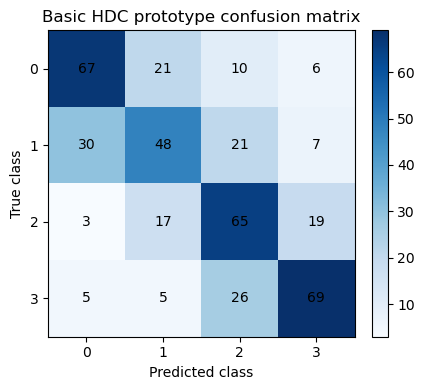

In [4]:
cm = confusion["Basic Prototype HDC"]
cm_df = pd.DataFrame(cm, index=["true_0", "true_1", "true_2", "true_3"], columns=["pred_0", "pred_1", "pred_2", "pred_3"])
cm_df.to_csv(RESULTS / "basic_hdc_prototype_confusion_matrix.csv")
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Basic HDC prototype confusion matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(range(4), labels=[0, 1, 2, 3])
ax.set_yticks(range(4), labels=[0, 1, 2, 3])
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURES / "basic_hdc_prototype_confusion_matrix.png", dpi=160)
plt.show()


## Interpretation for P1 defense

This notebook shows the HDC idea in executable form: feature-value binding, bundling into sample hypervectors, class prototype construction, and nearest-prototype inference.
It is a starting prototype before the formal HDC variant screening phase.
